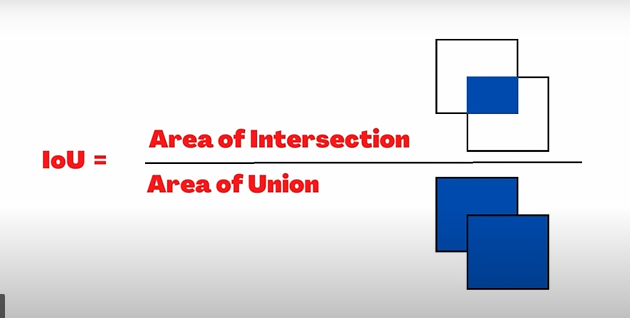

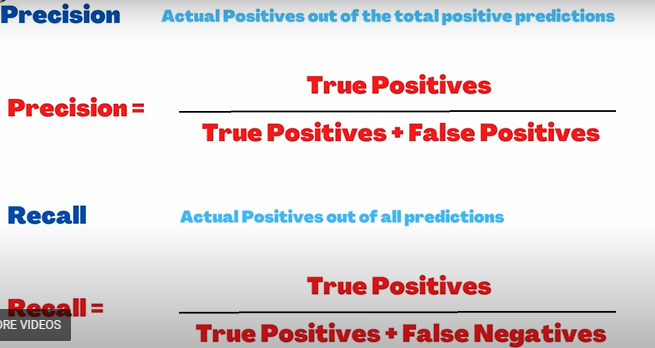

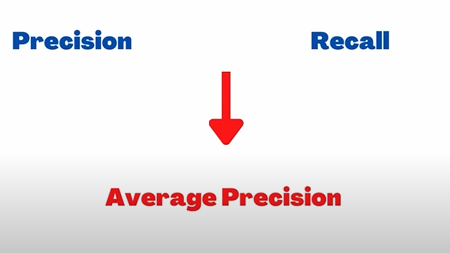

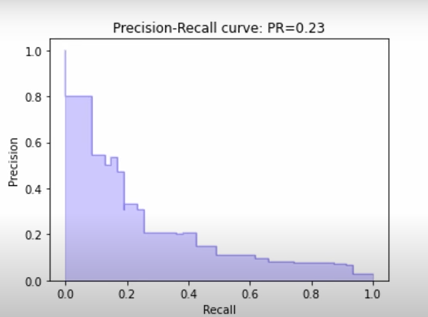

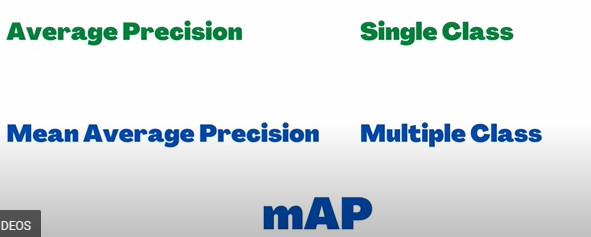

In [2]:
import cv2

In [3]:
from ultralytics import YOLO


In [3]:
model = YOLO('../model/yolov8l.pt')

100%|██████████| 83.7M/83.7M [00:21<00:00, 4.10MB/s]


In [4]:
results = model("../object_image/images.jpeg", show=True)


image 1/1 d:\a27_YEARS_OLD\yolo-5-object_detection\notebook\..\object_image\images.jpeg: 480x640 5 persons, 1 bus, 1 backpack, 4 handbags, 2046.4ms
Speed: 127.3ms preprocess, 2046.4ms inference, 202.0ms postprocess per image at shape (1, 3, 480, 640)


In [5]:
results = model("../object_image/images2.jpeg", show=True)


image 1/1 d:\a27_YEARS_OLD\yolo-5-object_detection\notebook\..\object_image\images2.jpeg: 384x640 3 cars, 5 trucks, 782.4ms
Speed: 2.2ms preprocess, 782.4ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


In [6]:
import cvzone
import math
import time
 
cap = cv2.VideoCapture(0)  # For Webcam
cap.set(3, 1280)
cap.set(4, 720)
# cap = cv2.VideoCapture("../Videos/motorbikes.mp4")  # For Video

True

In [8]:
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"
              ]

In [9]:
prev_frame_time = 0
new_frame_time = 0

In [17]:
while True:
    new_frame_time = time.time()
    success, img = cap.read()
    print("Success", success)
    results = model(img, stream=True)
    for r in results:
        boxes = r.boxes
        for box in boxes:
            # Bounding Box
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            # cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,255),3)
            w, h = x2 - x1, y2 - y1
            cvzone.cornerRect(img, (x1, y1, w, h))
            # Confidence
            conf = math.ceil((box.conf[0] * 100)) / 100
            # Class Name
            cls = int(box.cls[0])

            cvzone.putTextRect(img, f'{classNames[cls]} {conf}', (max(0, x1), max(35, y1)), scale=1, thickness=1)
 
    fps = 1 / (new_frame_time - prev_frame_time)
    prev_frame_time = new_frame_time
    print(fps)

    cv2.imshow("Image", img)
    cv2.waitKey(1)

Success True

0: 480x640 3 persons, 801.4ms
Speed: 4.6ms preprocess, 801.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
5.762439632633522e-10
Success True

0: 480x640 3 persons, 831.9ms
Speed: 3.6ms preprocess, 831.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
0.8170216479460719
Success True

0: 480x640 3 persons, 1 airplane, 843.1ms
Speed: 3.1ms preprocess, 843.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
0.8594080431402223
Success True

0: 480x640 3 persons, 867.2ms
Speed: 10.2ms preprocess, 867.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
0.844862023928368
Success True

0: 480x640 3 persons, 820.9ms
Speed: 3.0ms preprocess, 820.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
0.8304996616068073
Success True

0: 480x640 2 persons, 741.2ms
Speed: 7.0ms preprocess, 741.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
0.8686519122522197
Success True

0: 48

KeyboardInterrupt: 

car counter

In [1]:
import numpy as np
from ultralytics import YOLO
import cv2
import cvzone
import math



In [11]:
cap = cv2.VideoCapture("../object_image/car_v.mp4")  # For Video
 

In [4]:
model = YOLO('../model/yolov8l.pt')

In [16]:
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"
              ]
 

In [17]:
mask = cv2.imread("../object_image/mask.png")

In [21]:
from sort import Sort

In [22]:
# Tracking
tracker = Sort(max_age=20, min_hits=3, iou_threshold=0.3)

In [25]:
limits = [400, 297, 673, 297]
totalCount = []

In [12]:
while True:
    new_frame_time = time.time()
    success, img = cap.read()
    print("Success", success)
    results = model(img, stream=True)
    for r in results:
        boxes = r.boxes
        for box in boxes:
            # Bounding Box
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            # cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,255),3)
            w, h = x2 - x1, y2 - y1
            cvzone.cornerRect(img, (x1, y1, w, h),l=15)
            # Confidence
            conf = math.ceil((box.conf[0] * 100)) / 100
            # Class Name
            cls = int(box.cls[0])

            cvzone.putTextRect(img, f'{classNames[cls]} {conf}', (max(0, x1), max(35, y1)), scale=1, thickness=1)
 
    fps = 1 / (new_frame_time - prev_frame_time)
    prev_frame_time = new_frame_time
    print(fps)

    cv2.imshow("Image", img)
    cv2.waitKey(1)

Success True



0: 384x640 9 cars, 1 truck, 858.5ms
Speed: 72.1ms preprocess, 858.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
0.0320199465075099
Success True

0: 384x640 1 person, 9 cars, 1 truck, 660.5ms
Speed: 3.0ms preprocess, 660.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
0.9711910143787907
Success True

0: 384x640 9 cars, 1 traffic light, 914.0ms
Speed: 3.0ms preprocess, 914.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
1.4215449792833479
Success True

0: 384x640 3 persons, 9 cars, 1 traffic light, 695.9ms
Speed: 3.4ms preprocess, 695.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
1.0474400512644038
Success True

0: 384x640 1 person, 9 cars, 1 traffic light, 726.5ms
Speed: 5.0ms preprocess, 726.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
1.329916513677108
Success True

0: 384x640 9 cars, 1 traffic light, 693.2ms
Speed: 5.0ms preprocess, 693.2ms inference, 1.3ms postprocess per 

KeyboardInterrupt: 

In [29]:
while True:
    new_frame_time = time.time()
    success, img = cap.read()
    print("Success", success)
    imgRegion = cv2.bitwise_and(img, mask)
    # results = model(img, stream=True)
    results = model(imgRegion, stream=True)
    detections = np.empty((0, 5))
    for r in results:
        boxes = r.boxes
        for box in boxes:
            # Bounding Box
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            # cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,255),3)
            w, h = x2 - x1, y2 - y1
        
            # Confidence
            conf = math.ceil((box.conf[0] * 100)) / 100
            # Class Name
            cls = int(box.cls[0])
            currentClass = classNames[cls]
            
            if currentClass == "car" or currentClass == "truck" or currentClass == "bus" \
                    or currentClass == "motorbike" and conf > 0.3:
                # cvzone.putTextRect(img, f'{currentClass} {conf}', (max(0, x1), max(35, y1)),
                #                    scale=0.6, thickness=1, offset=3)
                # cvzone.cornerRect(img, (x1, y1, w, h), l=9, rt=5)
                currentArray = np.array([x1, y1, x2, y2, conf])
                detections = np.vstack((detections, currentArray))

    resultsTracker = tracker.update(detections)
    
    cv2.line(img, (limits[0], limits[1]), (limits[2], limits[3]), (0, 0, 255), 5)
    for result in resultsTracker:
        x1, y1, x2, y2, id = result
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        print(result)
        w, h = x2 - x1, y2 - y1
        cvzone.cornerRect(img, (x1, y1, w, h), l=9, rt=2, colorR=(255, 0, 255))
        cvzone.putTextRect(img, f' {int(id)}', (max(0, x1), max(35, y1)),
                           scale=2, thickness=3, offset=10)
        
        cx, cy = x1 + w // 2, y1 + h // 2
        cv2.circle(img, (cx, cy), 5, (255, 0, 255), cv2.FILLED)
 
        if limits[0] < cx < limits[2] and limits[1] - 15 < cy < limits[1] + 15:
            if totalCount.count(id) == 0:
                totalCount.append(id)
                cv2.line(img, (limits[0], limits[1]), (limits[2], limits[3]), (0, 255, 0), 5)

    # cvzone.putTextRect(img, f' Count: {len(totalCount)}', (50, 50))
    cv2.putText(img,str(len(totalCount)),(255,100),cv2.FONT_HERSHEY_PLAIN,5,(50,50,255),8)
 
    # fps = 1 / (new_frame_time - prev_frame_time)
    # prev_frame_time = new_frame_time
    # print(fps)

    cv2.imshow("Image", img)
    # cv2.imshow("ImageRegion", imgRegion)
    cv2.waitKey(1)

Success True



0: 384x640 4 cars, 879.6ms
Speed: 8.6ms preprocess, 879.6ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)
[     380.23      258.87      471.66      363.23          15]
[     476.47      300.48       590.9      365.66          14]
[     617.58      260.56      765.04      366.25           9]
Success True

0: 384x640 3 cars, 834.5ms
Speed: 5.5ms preprocess, 834.5ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)
[     381.16      258.13      473.66      363.59          15]
[      478.3      299.24      592.62      365.86          14]
[     621.39      260.03      770.56      366.16           9]
Success True

0: 384x640 4 cars, 887.0ms
Speed: 4.5ms preprocess, 887.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
[     381.61      257.95      475.42      363.66          15]
[     479.52      296.93       594.6      365.18          14]
[     622.81      260.43      771.84      366.84           9]
Success True

0: 384x640 3 cars, 1 suit

KeyboardInterrupt: 